In [1]:
%matplotlib widget
from pathlib import Path
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
Path.cwd()
data_dir = (Path.cwd().parents[1] / ".data/r-data").resolve()
assert data_dir.exists()

list(f"{pth.stem}{pth.suffix}" for pth in data_dir.glob("*"))

['gafa_stock.csv',
 'olympic_running.csv',
 'guinea_rice.csv',
 'aus_production.csv',
 'ansett.csv',
 'aus_retail.csv',
 'souvenirs.csv',
 'boston_marathon.csv',
 'PBS.csv',
 'prices.csv',
 'canadian_gas.csv',
 'insurance.csv',
 'pelt.csv',
 'tourism.csv',
 'us_employment.csv',
 'vic_elec.csv',
 'aus_airpassengers.csv',
 'bank_calls.csv',
 'aus_livestock.csv',
 'hh_budget.csv',
 'us_gasoline.csv',
 'aus_accommodation.csv',
 'aus_arrivals.csv',
 'us_change.csv',
 'pedestrian.csv',
 'LakeHuron.csv',
 'global_economy.csv']

In [2]:
df = (
    pd.read_csv(data_dir / "us_employment.csv")
    .assign(date= lambda df: pd.to_datetime(df.Month))
    .assign(year= lambda df: df.date.dt.year)
    .query("year >= 1990 and Title == 'Retail Trade'")
    .drop(columns=["year"])
    .set_index("date")
)
df

/var/folders/yl/_h6j91qd4d30w8vyy7hnlvjh0000gn/T/ipykernel_10357/977608873.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  .assign(date= lambda df: pd.to_datetime(df.Month))


,Month,Series_ID,Title,Employed
date,,,,
1990-01-01,1990 Jan,CEU4200000001,Retail Trade,13255.8
1990-02-01,1990 Feb,CEU4200000001,Retail Trade,12966.3
1990-03-01,1990 Mar,CEU4200000001,Retail Trade,12938.2
1990-04-01,1990 Apr,CEU4200000001,Retail Trade,13012.3
1990-05-01,1990 May,CEU4200000001,Retail Trade,13108.3
...,...,...,...,...
2019-05-01,2019 May,CEU4200000001,Retail Trade,15691.6
2019-06-01,2019 Jun,CEU4200000001,Retail Trade,15775.5
2019-07-01,2019 Jul,CEU4200000001,Retail Trade,15785.9


<Axes: xlabel='date'>

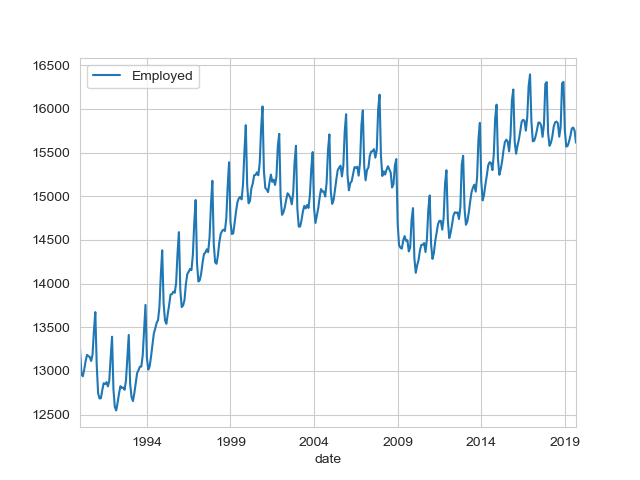

In [3]:
df.plot(y="Employed")

In [4]:
from statsmodels.tsa.seasonal import STL
stl = STL(df.Employed).fit()

In [5]:
#print all public attribs of stl
print([attr for attr in dir(stl) if not attr.startswith("_")])

['nobs', 'observed', 'plot', 'resid', 'seasonal', 'trend', 'weights']


In [6]:
# Add components to the original dataframe
df = df.assign(**stl.trend.to_frame("trend"),
               **stl.seasonal.to_frame("seasonal"),
               **stl.resid.to_frame("resid")
    )

In [7]:
df

,Month,Series_ID,Title,Employed,trend,seasonal,resid
date,,,,,,,
1990-01-01,1990 Jan,CEU4200000001,Retail Trade,13255.8,13296.248875,-3.699986,-36.748889
1990-02-01,1990 Feb,CEU4200000001,Retail Trade,12966.3,13276.085176,-288.398325,-21.386851
1990-03-01,1990 Mar,CEU4200000001,Retail Trade,12938.2,13255.662673,-306.657625,-10.805048
1990-04-01,1990 Apr,CEU4200000001,Retail Trade,13012.3,13234.986479,-235.775229,13.088750
1990-05-01,1990 May,CEU4200000001,Retail Trade,13108.3,13214.070964,-115.398800,9.627836
...,...,...,...,...,...,...,...
2019-05-01,2019 May,CEU4200000001,Retail Trade,15691.6,15784.875120,-76.457708,-16.817412
2019-06-01,2019 Jun,CEU4200000001,Retail Trade,15775.5,15778.842886,-1.628297,-1.714589
2019-07-01,2019 Jul,CEU4200000001,Retail Trade,15785.9,15772.740656,11.713653,1.445691


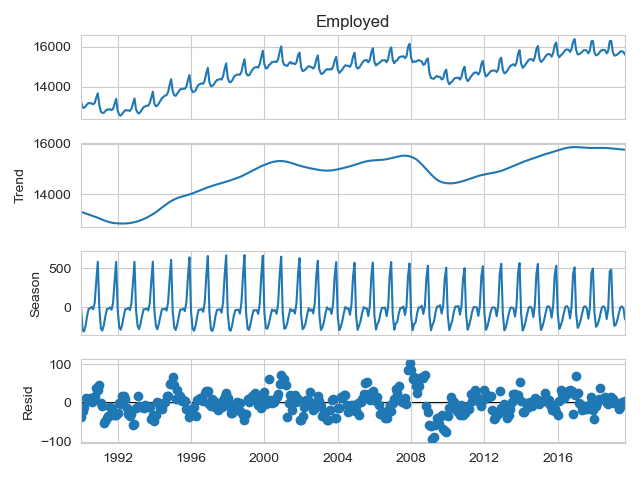

In [8]:
stl.plot()
plt.show();

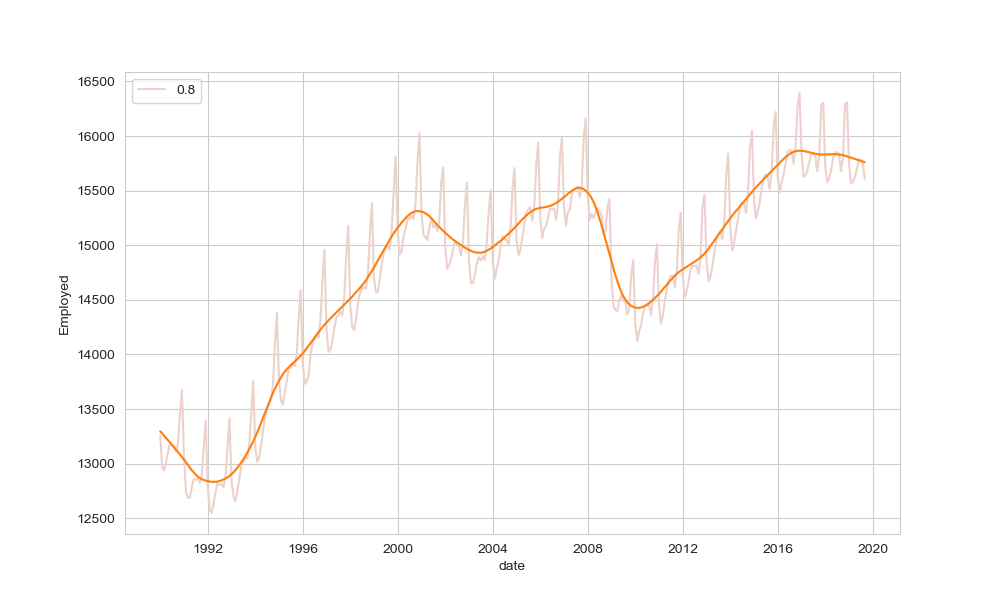

In [9]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x=df.index,
    y="Employed",
    hue=0.8,
    color="gray",
)
sns.lineplot(
    data=df,
    x=df.index,
    y="trend",
)
plt.show()

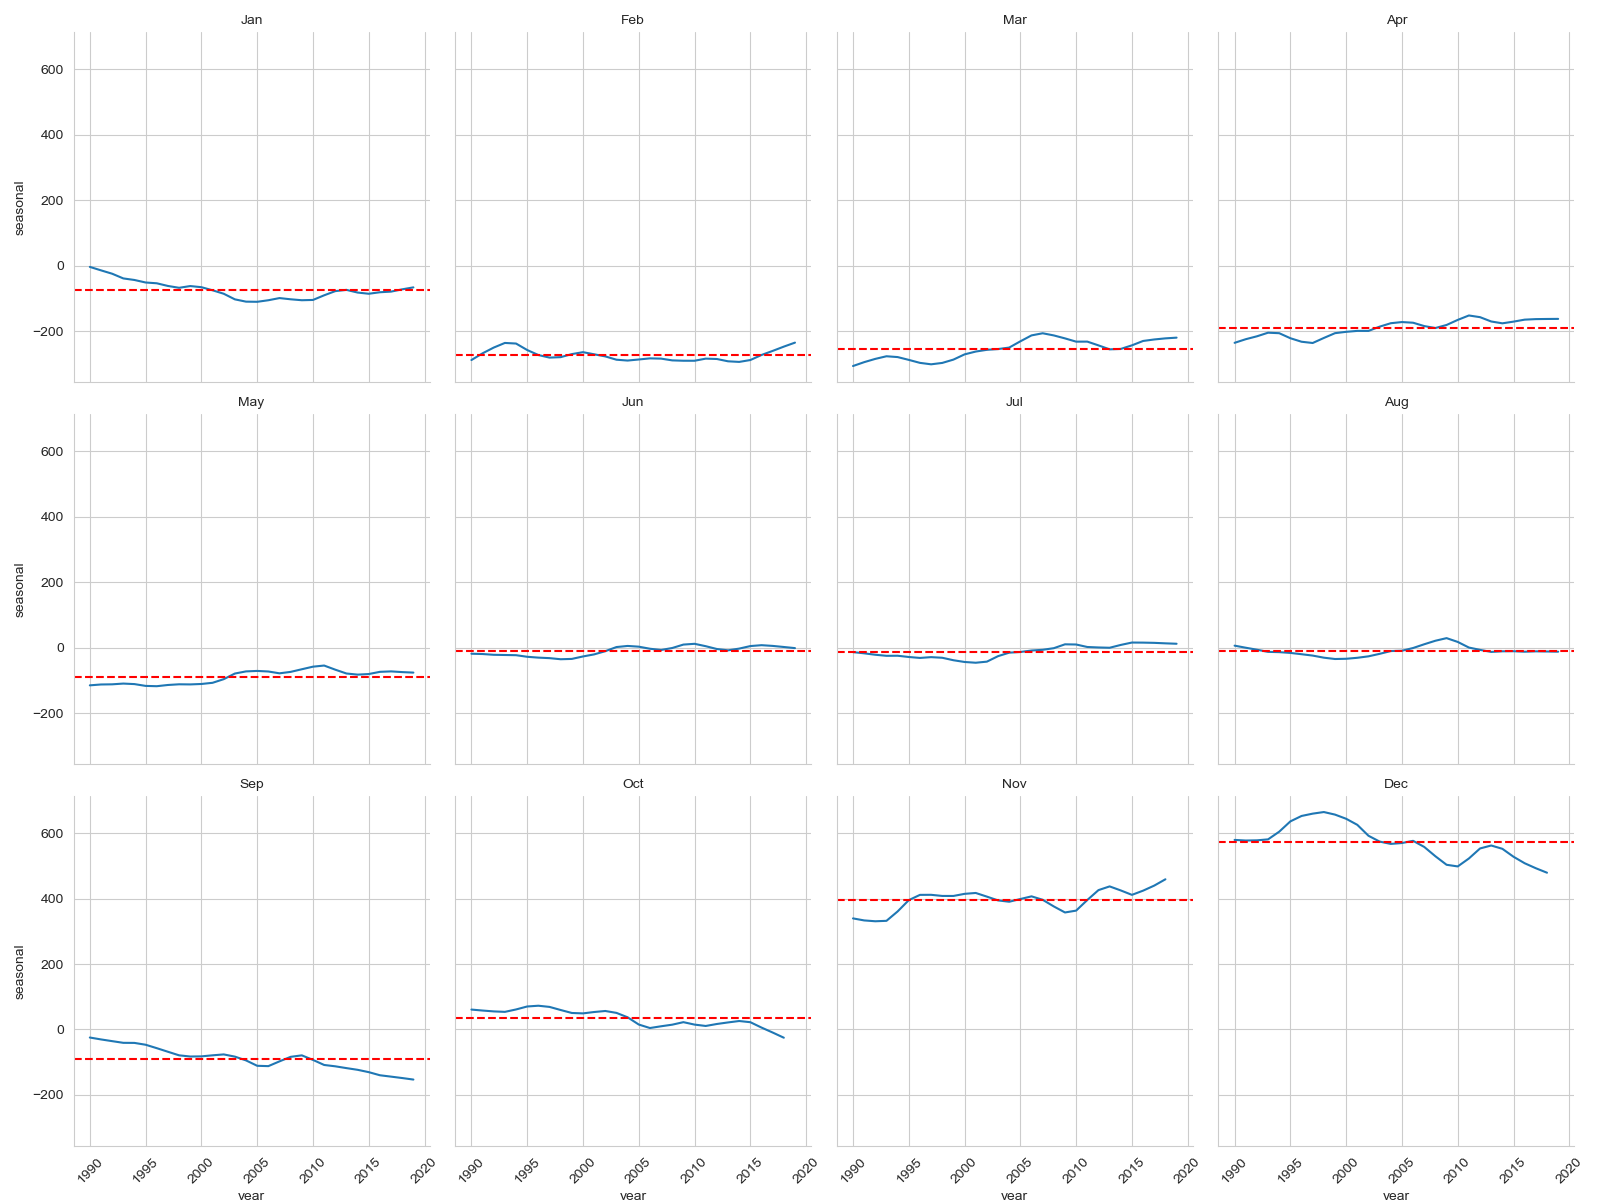

In [10]:
from tsa_helpers import subseries_plot

subseries_plot(df, period="month", value_col="seasonal", col_wrap=4, add_mean_line=True)

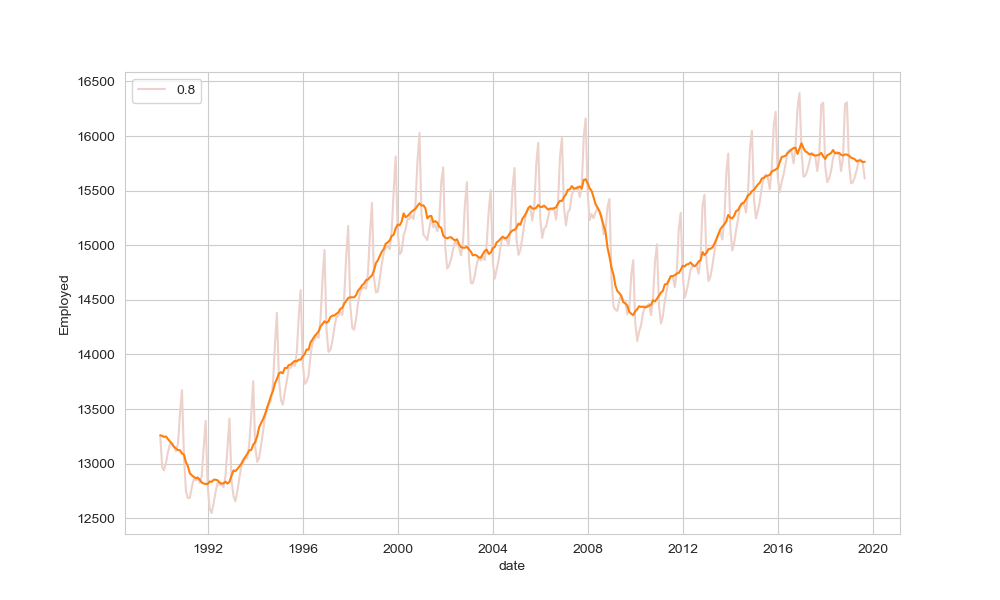

In [11]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x=df.index,
    y="Employed",
    hue=0.8,
    color="gray",
)
sns.lineplot(
    data=df.assign(seasonal_adjusted=df.Employed - df.seasonal,),
    x=df.index,
    y="seasonal_adjusted",
)
plt.show()

## Moving Averages

In [12]:
df = (
    pd.read_csv(data_dir / "global_economy.csv")
    .assign(year= lambda df: pd.to_datetime(df.Year, format="%Y"))
    .set_index("year")
    .query("Country == 'Australia'")
)
df.head()

,Country,Code,Year,GDP,Growth,CPI,Imports,Exports,Population
year,,,,,,,,,
1960-01-01,Australia,AUS,1960,1.857319e+10,NaN,7.960458,14.061746,12.994452,10276477.0
1961-01-01,Australia,AUS,1961,1.964834e+10,2.485605,8.142560,15.025080,12.403101,10483000.0
1962-01-01,Australia,AUS,1962,1.988801e+10,1.296478,8.116545,12.630927,13.943012,10742000.0
1963-01-01,Australia,AUS,1963,2.150185e+10,6.214278,8.168574,13.834054,13.005886,10950000.0
1964-01-01,Australia,AUS,1964,2.375854e+10,6.978724,8.402706,13.764495,14.938248,11167000.0


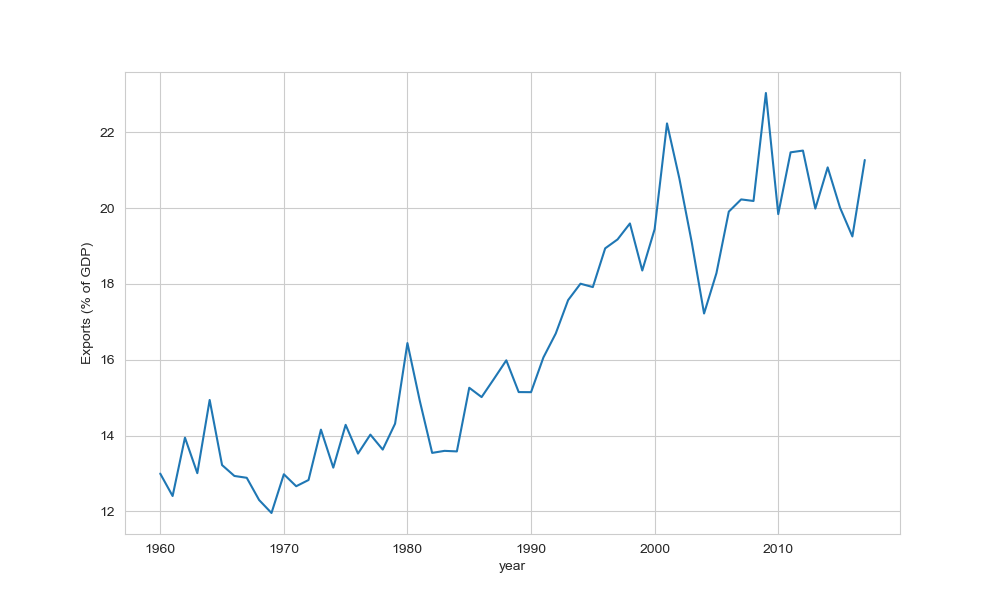

In [13]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x=df.index,
    y="Exports",
)
plt.ylabel(r"Exports (% of GDP)")
plt.show()

In [14]:
ma_windows = [3, 7, 13]
df_ma = df.assign(
    **{
        f"Exports_MA{window}": df["Exports"].rolling(window=window, center=True).mean()
        for window in ma_windows
    }
)
df_ma

,Country,Code,Year,GDP,Growth,CPI,Imports,Exports,Population,Exports_MA3,Exports_MA7,Exports_MA13
year,,,,,,,,,,,,
1960-01-01,Australia,AUS,1960,1.857319e+10,NaN,7.960458,14.061746,12.994452,10276477.0,NaN,NaN,NaN
1961-01-01,Australia,AUS,1961,1.964834e+10,2.485605,8.142560,15.025080,12.403101,10483000.0,13.113522,NaN,NaN
1962-01-01,Australia,AUS,1962,1.988801e+10,1.296478,8.116545,12.630927,13.943012,10742000.0,13.117333,NaN,NaN
1963-01-01,Australia,AUS,1963,2.150185e+10,6.214278,8.168574,13.834054,13.005886,10950000.0,13.962382,13.348180,NaN
1964-01-01,Australia,AUS,1964,2.375854e+10,6.978724,8.402706,13.764495,14.938248,11167000.0,13.721437,13.332362,NaN
1965-01-01,Australia,AUS,1965,2.593124e+10,5.983450,8.688866,15.267340,13.220178,11388000.0,13.696936,13.317300,NaN
1966-01-01,Australia,AUS,1966,2.726173e+10,2.382491,8.975026,15.130228,12.932380,11651000.0,13.012096,13.033278,13.002891
1967-01-01,Australia,AUS,1967,3.038974e+10,6.302386,9.287201,13.893495,12.883730,11799000.0,12.704593,13.029157,13.092166
1968-01-01,Australia,AUS,1968,3.265763e+10,5.095868,9.521332,14.485597,12.297668,12009000.0,12.378752,12.703875,13.149773


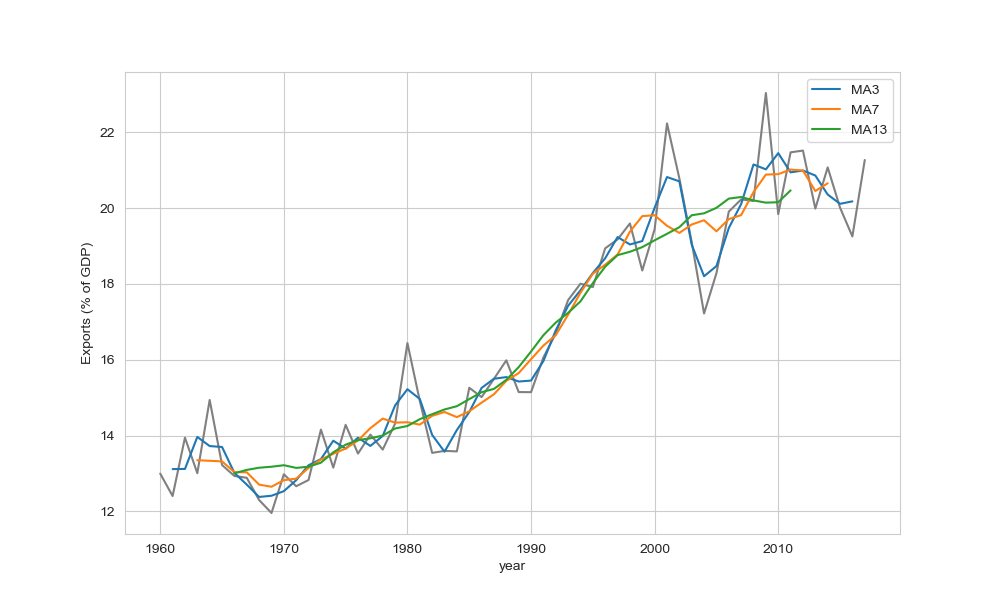

In [15]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_ma,
    x=df_ma.index,
    y="Exports",
    color="gray",
)
for window in ma_windows:
    sns.lineplot(
        data=df_ma,
        x=df_ma.index,
        y=f"Exports_MA{window}",
        label=f"MA{window}",
    )
plt.ylabel(r"Exports (% of GDP)")
plt.show()

/var/folders/yl/_h6j91qd4d30w8vyy7hnlvjh0000gn/T/ipykernel_10357/819062318.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  .assign(date=lambda df: pd.to_datetime(df.Month))


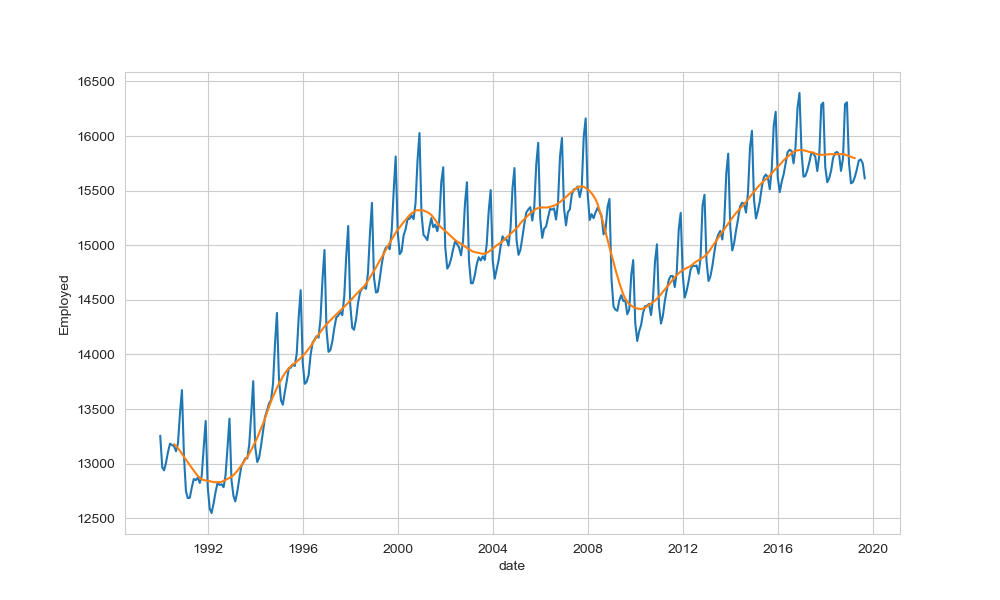

In [16]:
df = (
    pd.read_csv(data_dir / "us_employment.csv")
    .assign(date=lambda df: pd.to_datetime(df.Month))
    .assign(year=lambda df: df.date.dt.year)
    .query("year >= 1990 and Title == 'Retail Trade'")
    .drop(columns=["year"])
    .set_index("date")
)

## apply 2 x 12 MA
df = df.assign(
    Employed_MA2x12=df["Employed"]
    .rolling(window=12, center=True)
    .mean()
    .rolling(window=2, center=True)
    .mean()
)
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x=df.index,
    y="Employed",
)
sns.lineplot(
    data=df,
    x=df.index,
    y="Employed_MA2x12",
)
plt.show()

## Classical Decomposition

In [17]:
df = (
    df
    .assign(
        SR=df.Employed - df.Employed_MA2x12
    )
    .assign(
        S=lambda df: df.SR.groupby(df.index.month).transform("mean")
    )
    .assign(
        R=lambda df: df.SR - df.S
    )
)
df

,Month,Series_ID,Title,Employed,Employed_MA2x12,SR,S,R
date,,,,,,,,
1990-01-01,1990 Jan,CEU4200000001,Retail Trade,13255.8,NaN,NaN,-67.996695,NaN
1990-02-01,1990 Feb,CEU4200000001,Retail Trade,12966.3,NaN,NaN,-265.590517,NaN
1990-03-01,1990 Mar,CEU4200000001,Retail Trade,12938.2,NaN,NaN,-245.904598,NaN
1990-04-01,1990 Apr,CEU4200000001,Retail Trade,13012.3,NaN,NaN,-182.183764,NaN
1990-05-01,1990 May,CEU4200000001,Retail Trade,13108.3,NaN,NaN,-80.845685,NaN
...,...,...,...,...,...,...,...,...
2019-05-01,2019 May,CEU4200000001,Retail Trade,15691.6,NaN,NaN,-80.845685,NaN
2019-06-01,2019 Jun,CEU4200000001,Retail Trade,15775.5,NaN,NaN,-2.274107,NaN
2019-07-01,2019 Jul,CEU4200000001,Retail Trade,15785.9,NaN,NaN,-5.614435,NaN


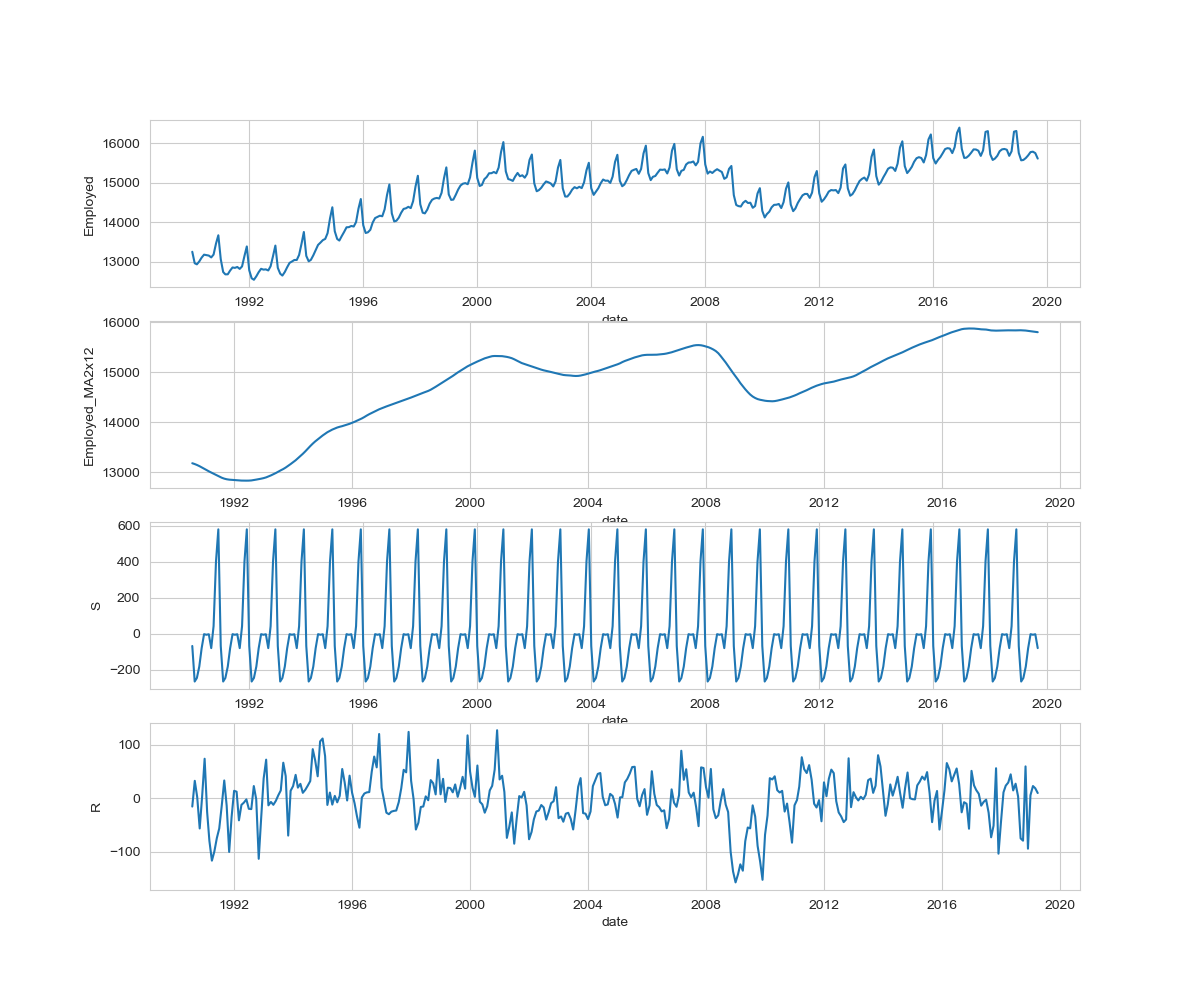

In [18]:
_, axes = plt.subplots(4, 1, figsize=(12, 10))
for ax, col in zip(axes, ["Employed", "Employed_MA2x12", "S", "R"]):
    sns.lineplot(
        data=df,
        x=df.index,
        y=col,
        ax=ax,
    )

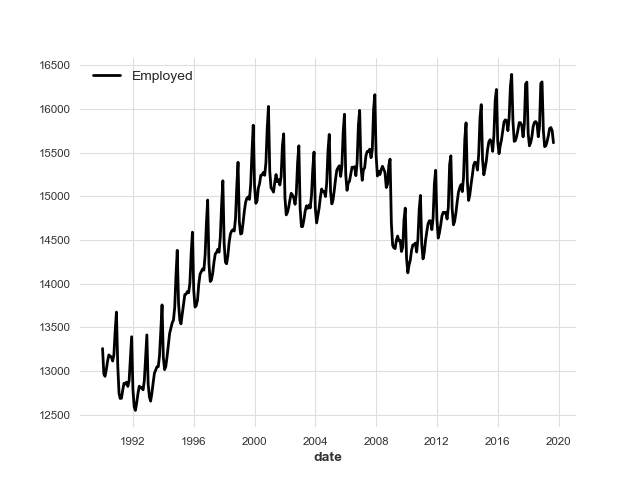

In [30]:
# import X11 from darts
from darts import TimeSeries
from darts.utils.statistics import seasonal_decompose


ts = TimeSeries.from_dataframe(df, time_col=None, value_cols="Employed")

ts.plot(new_plot=True)
plt.show()

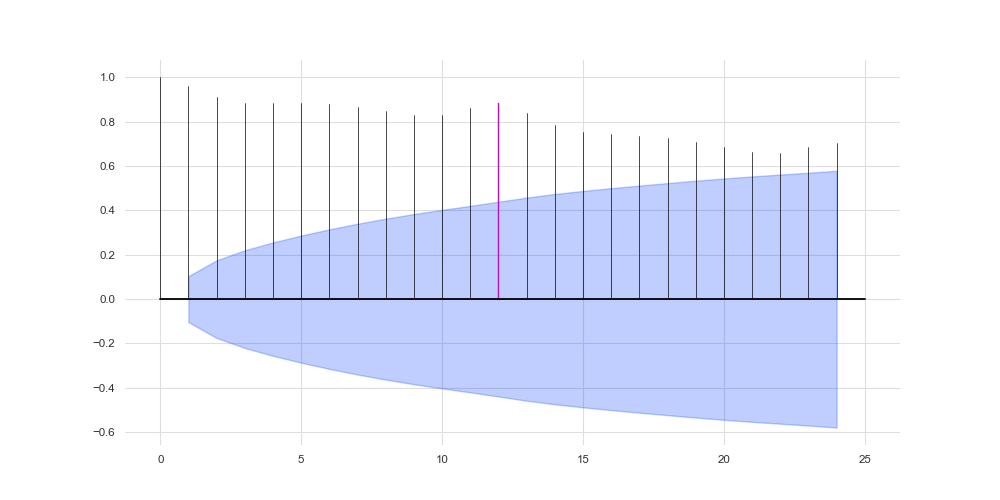

In [33]:
from darts.utils.statistics import plot_acf
plot_acf(ts, m=12)

In [44]:
import matplotlib.pyplot as plt
from ipywidgets import interact
from darts.dataprocessing.transformers import BoxCox

@interact(lmbda=(-2.0, 2.0, 0.01))
def plot_boxcox(lmbda):
    transformer = BoxCox(lmbda=lmbda)
    transformed_ts = transformer.fit_transform(ts)
    plt.figure(figsize=(10, 6))
    transformed_ts.plot(label=f'Box-Cox Transformed (lambda={lmbda})')
    plt.legend()
    plt.show()

interact(plot_boxcox, lmbda=(-2.0, 2.0, 0.01))

interactive(children=(FloatSlider(value=0.0, description='lmbda', max=2.0, min=-2.0, step=0.01), Output()), _d…

interactive(children=(FloatSlider(value=0.0, description='lmbda', max=2.0, min=-2.0, step=0.01), Output()), _d…

<function __main__.plot_boxcox(lmbda)>

In [66]:
## STL decomposition using darts

from darts.utils.statistics import seasonal_decompose

stl = seasonal_decompose(ts, period=12)

ValueError: setting an array element with a sequence. The requested array would exceed the maximum number of dimension of 32.